# Multi-Factor Extension: Counting Detectable Spikes

This notebook extends the one-factor spiked covariance experiment to a finite-rank factor model.

We study

$$
A = F L^T + E,
$$

where

$$
A \in \mathbb{R}^{T \times N}, \qquad F \in \mathbb{R}^{T \times k}, \qquad L \in \mathbb{R}^{N \times k}.
$$

The columns of L are fixed true loading directions, and we assume

$$
L^T L = I_k.
$$

The factor covariance is diagonal:

$$
\mathrm{Cov}(f_t) = \mathrm{diag}(\tau_1^2, \ldots, \tau_k^2),
$$

so the population covariance is

$$
\Sigma = \sigma^2 I_N + L\,\mathrm{diag}(\tau_1^2,\ldots,\tau_k^2)L^T.
$$

This gives k population spikes:

$$
\sigma^2 + \tau_1^2, \ldots, \sigma^2 + \tau_k^2.
$$

The goal is not to match individual sample eigenvalues to individual factors. Instead, we ask whether the number of sample outliers is close to the number of supercritical population spikes predicted by BBP theory.


## BBP Prediction for Multiple Factors

Let

$$
q = \frac{N}{T}.
$$

For factor i, define normalized spike strength

$$
\theta_i = \frac{\tau_i^2}{\sigma^2}.
$$

The BBP threshold is

$$
\theta_i > \sqrt q.
$$

Equivalently,

$$
\tau_i > \tau_c = \sigma q^{1/4}.
$$

In the high-dimensional asymptotic regime, supercritical factors may create separated sample eigenvalue outliers. Subcritical factors are expected to remain absorbed in the MP bulk.

In finite samples, this is not deterministic. Therefore we repeat the experiment many times and look at the distribution of the number of observed outliers.


In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")


In [22]:
def center_columns(A):
    """Subtract each column's sample mean."""
    return A - A.mean(axis=0, keepdims=True)


def sample_covariance(A, center=True):
    """Return centered C = X^T X / T for A in R^{T x N}."""
    X = center_columns(A) if center else A
    T = X.shape[0]
    return X.T @ X / T


def top_eigenpair(C):
    """Return eigenvalues/eigenvectors of symmetric C in descending order."""
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]


def random_orthonormal_loadings(N, k, rng):
    """Generate N x k orthonormal loading directions."""
    Q, _ = np.linalg.qr(rng.normal(size=(N, k)))
    return Q[:, :k]


def subspace_alignment(V_hat, L_true):
    """
    Compare two m-dimensional subspaces.

    V_hat and L_true are N x m matrices. The score equals 1 when the
    subspaces are identical and is near 0 when they are nearly orthogonal.
    """
    V_hat, _ = np.linalg.qr(V_hat)
    L_true, _ = np.linalg.qr(L_true)
    m = L_true.shape[1]
    return np.linalg.norm(V_hat.T @ L_true, ord="fro")**2 / m


def mp_edges(q, sigma2=1.0):
    """Marchenko-Pastur lower and upper edges."""
    low = sigma2 * (1 - np.sqrt(q)) ** 2
    high = sigma2 * (1 + np.sqrt(q)) ** 2
    return low, high


## Experiment Setup

We keep the same scale as the one-factor experiment:

$$
T = 600, \qquad N = 180, \qquad q = 0.3, \qquad \sigma = 1.
$$

The BBP critical factor strength is

$$
\tau_c = \sigma q^{1/4} \approx 0.740.
$$

We choose three factors:

$$
(\tau_1, \tau_2, \tau_3) = (1.6, 0.9, 0.5).
$$

The first two are above the BBP threshold, while the third is below it. Therefore the predicted number of detectable sample outliers is 2.


In [24]:
T = 600
N = 180
k = 3
q = N / T
sigma = 1.0
sigma2 = sigma**2

taus = np.array([1.6, 0.9, 0.5])
thetas = (taus / sigma) ** 2

theta_crit = np.sqrt(q)
tau_crit = sigma * q**0.25
mp_low, mp_high = mp_edges(q, sigma2=sigma2)

supercritical_mask = taus > tau_crit
m_detectable = int(np.sum(supercritical_mask))

print(f"T={T}, N={N}, q=N/T={q:.3f}")
print(f"sigma = {sigma:.3f}")
print(f"MP upper edge = {mp_high:.3f}")
print(f"BBP critical tau = {tau_crit:.3f}")
print(f"factor strengths tau = {taus}")
print(f"normalized strengths theta = {thetas}")
print(f"predicted detectable factors = {m_detectable}")


T=600, N=180, q=N/T=0.300
sigma = 1.000
MP upper edge = 2.395
BBP critical tau = 0.740
factor strengths tau = [1.6 0.9 0.5]
normalized strengths theta = [2.56 0.81 0.25]
predicted detectable factors = 2


## Simulation

We fix one loading matrix L for the whole experiment. Across trials, we resample the factor matrix F and the noise matrix E.

For each trial, we compute:

1. The eigenvalues of the sample covariance matrix.
2. The number of observed outliers above the MP upper edge.
3. A sample-adaptive subspace alignment score.

For the alignment score, we use the observed number of outliers in that trial:

$$
m_{obs} = \#\{\lambda_i(C)>\lambda_+\}.
$$

Then we compare the leading sample eigenspace with the first m_obs true loading directions:

$$
\frac{1}{m_{obs}}\|\hat V_{m_{obs}}^T L_{m_{obs}}\|_F^2.
$$

If m_obs = 0, the alignment is undefined and we store NaN. If finite-sample noise produces more observed outliers than k, we cap m_obs at k for the subspace comparison.


In [26]:
rng = np.random.default_rng(123)
n_trials = 50

# Fixed true loading directions for the whole experiment.
L = random_orthonormal_loadings(N, k, rng)

outlier_counts = []
subspace_scores = []
subspace_dims = []
full_k_scores = []
detectable_m_scores = []
eigs_all = []

for _ in range(n_trials):
    F = rng.normal(0.0, taus, size=(T, k))
    E = rng.normal(0.0, sigma, size=(T, N))
    A = F @ L.T + E

    C = sample_covariance(A, center=True)
    vals, vecs = top_eigenpair(C)

    m_obs = int(np.sum(vals > mp_high))
    m_align = min(m_obs, k)

    outlier_counts.append(m_obs)
    subspace_dims.append(m_align)
    eigs_all.append(vals)

    full_k_scores.append(subspace_alignment(vecs[:, :k], L))
    if m_detectable == 0:
        detectable_m_scores.append(np.nan)
    else:
        V_detectable = vecs[:, :m_detectable]
        L_detectable = L[:, supercritical_mask]
        detectable_m_scores.append(subspace_alignment(V_detectable, L_detectable))

    if m_align == 0:
        subspace_scores.append(np.nan)
    else:
        V_hat = vecs[:, :m_align]
        L_true = L[:, :m_align]
        subspace_scores.append(subspace_alignment(V_hat, L_true))

outlier_counts = np.array(outlier_counts)
subspace_dims = np.array(subspace_dims)
subspace_scores = np.array(subspace_scores, dtype=float)
full_k_scores = np.array(full_k_scores, dtype=float)
detectable_m_scores = np.array(detectable_m_scores, dtype=float)
eigs_all = np.array(eigs_all)

valid_scores = subspace_scores[~np.isnan(subspace_scores)]

print(f"mean observed outlier count = {outlier_counts.mean():.2f}")
print(f"std observed outlier count  = {outlier_counts.std():.2f}")
print(f"trials with defined alignment = {len(valid_scores)} / {n_trials}")
print(f"mean sample-adaptive subspace alignment = {np.nanmean(subspace_scores):.3f}")
print(f"std sample-adaptive subspace alignment  = {np.nanstd(subspace_scores):.3f}")
print(f"mean full-k recovery score = {np.nanmean(full_k_scores):.3f}")
print(f"mean detectable-m recovery score = {np.nanmean(detectable_m_scores):.3f}")


mean observed outlier count = 1.88
std observed outlier count  = 0.43
trials with defined alignment = 50 / 50
mean sample-adaptive subspace alignment = 0.656
std sample-adaptive subspace alignment  = 0.111


## Experiment 1: Outlier Count Distribution

This plot compares the observed number of sample eigenvalues above the MP edge with the predicted number of supercritical factors.

We should not expect a deterministic finite-sample match in every trial. The point is to see whether the distribution concentrates near the BBP-predicted count.


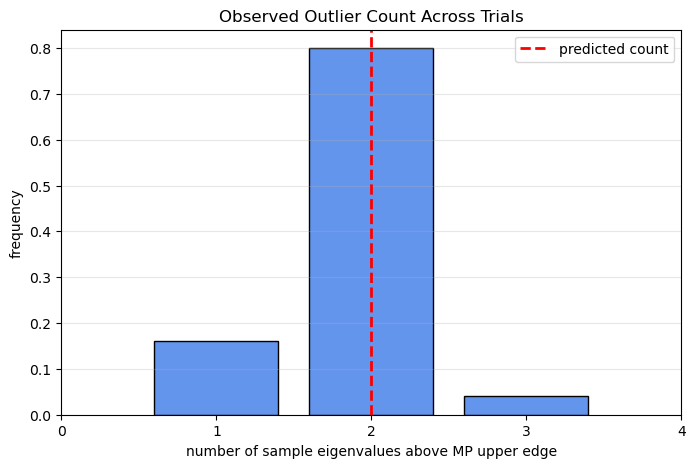

In [28]:
unique_counts, counts = np.unique(outlier_counts, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(unique_counts, counts / n_trials, color="cornflowerblue", edgecolor="black")
plt.axvline(m_detectable, color="red", linestyle="--", linewidth=2, label="predicted count")
plt.xticks(np.arange(0, max(outlier_counts.max(), m_detectable) + 2))
plt.xlabel("number of sample eigenvalues above MP upper edge")
plt.ylabel("frequency")
plt.title("Observed Outlier Count Across Trials")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## Experiment 2: A Representative Sample Spectrum

This plot shows one representative sample spectrum from the simulation trials above.

We choose a trial whose observed outlier count is closest to the BBP-predicted count. This is not an additional theoretical object; it is just one actual sample covariance spectrum from the repeated experiment.

The MP upper edge is shown in red. The number of eigenvalues above this line is the observed outlier count for that sample.


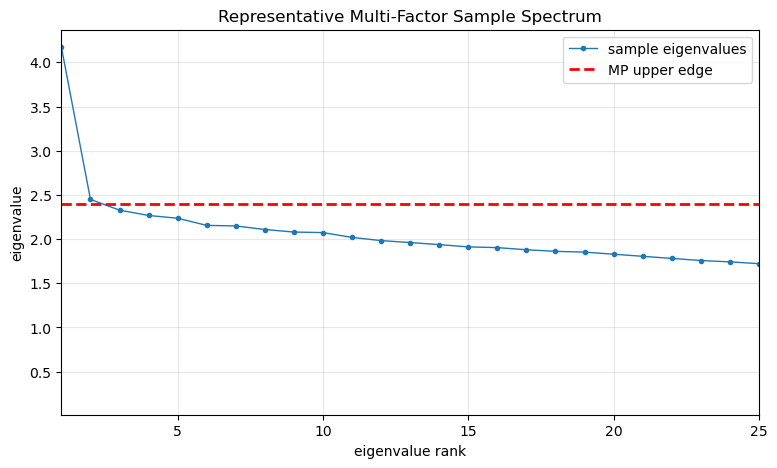

representative trial index = 0
observed outliers in representative spectrum = 2
BBP-predicted detectable count = 2
top 6 eigenvalues = [4.17123081 2.44850845 2.32759231 2.26735437 2.2359383  2.15528331]


In [30]:
rep = np.argmin(np.abs(outlier_counts - m_detectable))
vals = eigs_all[rep]

plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, N + 1), vals, marker="o", markersize=3, linewidth=1, label="sample eigenvalues")
plt.axhline(mp_high, color="red", linestyle="--", linewidth=2, label="MP upper edge")
plt.xlim(1, 25)
plt.xlabel("eigenvalue rank")
plt.ylabel("eigenvalue")
plt.title("Representative Multi-Factor Sample Spectrum")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"representative trial index = {rep}")
print(f"observed outliers in representative spectrum = {np.sum(vals > mp_high)}")
print(f"BBP-predicted detectable count = {m_detectable}")
print(f"top 6 eigenvalues = {vals[:6]}")


## Experiment 3: Sample-Adaptive Subspace Alignment

In the multi-factor case, individual sample eigenvectors should not be matched one-to-one with individual true factors. Sample eigenvectors can rotate within the factor subspace.

Here we use the observed outlier count in each trial. If m_obs sample eigenvalues are above the MP edge, we compare the leading m_obs-dimensional sample eigenspace with the first m_obs true loading directions:

$$
\frac{1}{m_{obs}}\|\hat V_{m_{obs}}^T L_{m_{obs}}\|_F^2.
$$

This makes the alignment score conditional on what the sample spectrum actually detects. Trials with m_obs = 0 have undefined alignment and are excluded from the histogram.


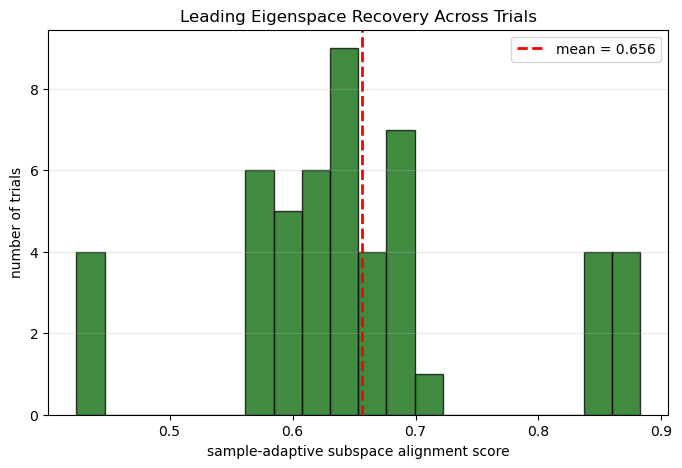

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(valid_scores, bins=20, color="darkgreen", edgecolor="black", alpha=0.75)
plt.axvline(np.nanmean(subspace_scores), color="red", linestyle="--", linewidth=2, label=f"mean = {np.nanmean(subspace_scores):.3f}")
plt.xlabel("sample-adaptive subspace alignment score")
plt.ylabel("number of trials")
plt.title("Leading Eigenspace Recovery Across Trials")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()


## Experiment 4: Full k Recovery vs Detectable m Recovery

The population model has k true loading directions, but BBP theory only suggests recovery for the supercritical part of the signal. In this setup, k = 3 while the BBP-predicted detectable dimension is

$$
m = \#\{i:\tau_i^2/\sigma^2 > \sqrt q\}.
$$

Therefore we compare two different recovery questions:

1. Full-factor recovery: compare the top k sample PCs with all k true loading directions.
2. Detectable-factor recovery: compare the top m sample PCs with only the m supercritical loading directions.

If the weakest factor is subcritical, the second score should be more stable and usually larger. This is the more precise BBP-style recovery statement. PCA is expected to recover the detectable loading subspace, not necessarily the full generating subspace.


In [ ]:
plot_rng = np.random.default_rng(7)

scores = [full_k_scores, detectable_m_scores]
labels = [
    f"top k PCs vs all k loadings\n(k={k})",
    f"top m PCs vs detectable loadings\n(m={m_detectable})",
]
colors = ["slateblue", "seagreen"]

plt.figure(figsize=(8, 5))
box = plt.boxplot(
    scores,
    labels=labels,
    patch_artist=True,
    showmeans=True,
    meanline=True,
)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

for i, score in enumerate(scores, start=1):
    jitter = plot_rng.normal(0.0, 0.035, size=len(score))
    plt.scatter(np.full(len(score), i) + jitter, score, color=colors[i - 1], alpha=0.55, s=28)

plt.ylim(0, 1.02)
plt.ylabel("subspace alignment score")
plt.title("Full k Recovery vs Detectable m Recovery")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("Imperial_College_London_Poster_Template/Images/research_figures/multi_factor_k_vs_m_recovery.pdf", bbox_inches="tight")
plt.savefig("Imperial_College_London_Poster_Template/Images/research_figures/multi_factor_k_vs_m_recovery.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"mean full-k recovery score = {np.nanmean(full_k_scores):.3f}")
print(f"mean detectable-m recovery score = {np.nanmean(detectable_m_scores):.3f}")
print(f"BBP-predicted detectable dimension m = {m_detectable} out of k = {k}")


## Interpretation

This extension illustrates the multi-factor version of the BBP intuition:

- We do not claim a one-to-one match between individual sample eigenvalues and individual real factors.
- Instead, the predicted count is the number of population spikes above the BBP threshold.
- In finite samples, the observed outlier count can fluctuate, especially near the threshold.
- For subspace recovery, we use the observed outlier count in each trial and compare the detected leading sample eigenspace with the corresponding true loading subspace.

For this setup, two factors are supercritical and one is subcritical. Therefore BBP theory predicts roughly two detectable sample outliers, while the weakest factor is expected to remain absorbed in the MP bulk.
